# Personal Information
### Full name: Kleanthis Vasileiadis
### sdi: 1115202200017   

# libraries


In [70]:
#Library used for copying
import copy
#Library used for reading the data
import pandas as pd
#Libraries used for working with arrays
import numpy as np 
#Libraries used for data visualization and plotting
import matplotlib.pyplot as plt
pd.plotting.register_matplotlib_converters()
%matplotlib inline
import seaborn as sns
#Libraries used for data preprocessing
import re
import string
import emoji
import nltk
#Libraries used for vectorization
import gensim
from gensim.models import Word2Vec, KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec
import random
#Library used for the neural network
import torch
import torch.nn as nn                     
import torch.optim as optim             
from torch.utils.data import Dataset, DataLoader, TensorDataset
#Library for optimization
import optuna
#Libraries used for evaluation
from sklearn.metrics import accuracy_score, roc_curve, auc, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
#Running the neural network on gpu if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#Setting random seed for reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# loading and reading the data

In [71]:
train_data = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/train_dataset.csv")
print(f"Training data")
print(train_data.head(5))
print(f"\n")

val_data = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/val_dataset.csv")
print(f"Validation data")
print(val_data.head(5))
print(f"\n")

test_data = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/test_dataset.csv")
print(f"Testing data")
print(test_data.head(5))

Training data
       ID                                               Text  Label
0  189385      @whoisralphie dude  I'm so bummed ur leaving!      0
1   58036  oh my god, a severed foot was foun in a wheely...      0
2  190139  I end up &quot;dog dialing&quot; sumtimes. Wha...      1
3   99313                         @_rachelx meeeee toooooo!       0
4  157825  I was hoping I could stay home and work today,...      0


Validation data
       ID                                               Text  Label
0  187062  @NatexTheGreat heyheyhey maybe i will  get the...      0
1  168997  @molliesmummy Work? Work was crap. I missed yo...      0
2  194461  Want: Trip to Boston next month. Need: Addit'l...      1
3  165442                        first day starts tomorrow!       1
4   34853  @goodforyoursoul 8 course fish in Little Saigo...      1


Testing data
       ID                                               Text
0  102388  The books ARRIVED!!! Those who want a copy - w...
1  153802  @Spu

# Text preprocessing

## Lists and dictionaries of tokens to be replaced

In [72]:
negation_words = {
            "not", "no", "never", "cannot", "won't", "don't", "doesn't", "isn't",
            "wasn't", "shouldn't", "couldn't", "wouldn't", "ain't", "didn't",
            "can't", "haven't", "hasn't", "nt", "wont", "dont", "doesnt", "isnt",
            "wasnt", "shouldnt", "couldnt", "wouldnt", "aint", "didnt"}

html_entities = {
            "&quot;": '"',         
            "&amp;": "and",         
            "&lt;": "less than",    
            "&gt;": "greater than"}

emoticons = {
        "<3": "love", 
        ":)": "happy", 
        ":-)": "happy", 
        ";)": "wink", 
        ":D": "laugh",
        ":(": "sad",
        ":o": "surprised",
        "XD": "laughing",
        "xD": "laughing",
        ":|": "neutral"}

names = [
    "john", "mary", "michael", "sarah", "james", "jennifer", "david", "robert", 
    "elizabeth", "william", "barbara", "richard", "susan", "joseph", "thomas", 
    "nancy", "charles", "karen", "betty", "matthew", "sandra", "anthony", "ashley", 
    "mark", "kimberly", "donald", "emily", "steven", "brian", "george", "edward", 
    "kevin", "ronald", "timothy", "becky", "farrah", "lisa", "alex", "kevin", "jenna", 
    "natalie", "matt", "bryan", "paul", "susan", "nikki", "carlos", "ben", "greta",
    "phil", "mia"]

places = [
    "nyc", "los angeles", "chicago", "houston","philadelphia","san antonio", "san diego",
    "dallas", "san jose", "austin", "jacksonville", "fort worth", "columbus", "san francisco",
    "charlotte", "seattle", "denver", "washington", "boston", "el paso", "nashville", "detroit", 
    "memphis", "portland", "las vegas", "louisville", "china", "asia", "america", "glasgow", 
    "melbourne", "dublin", "sydney", "california", "la", "tennesse", "dc", "texas", "portland", 
    "barcelona", "mexico", "australia", "europe", "germany", "spain", "alaska", "vancouver", 
    "munich", "greece", "japan", "mississippi", "peru", "bristol", "argentina", "denmark"]

terrains = [
        "island", "city", "town", "village", "country", "continent", "desert", "ocean", "river", 
        "mountain", "valley", "forest", "jungle", "beach", "canal", "county"]

## Text preprocessing functions

In [73]:
#Replacing terrains
def replace_terrains(text):
    for terrain in terrains:
        text = re.sub(rf"\b{terrain}\b", "terrain", text, flags=re.IGNORECASE)
    return text
    
#Replacing emoticons
def replace_emoticons(text):
    for emoticon, replacement in emoticons.items():
        text = text.replace(emoticon, replacement)
    return text
    
#Replacing places
def replace_places(text):
    for place in places:
        text = re.sub(rf"\b{place}\b", "place", text, flags=re.IGNORECASE)
    return text

#Replacing names
def replace_names(text):
    for name in names:
        text = re.sub(rf"\b{name}\b", "name", text, flags=re.IGNORECASE)
    return text

#Replacing html_entities
def replace_html_entities(text):
    for entity, char in html_entities.items():
        text = text.replace(entity, char)
    return text

#Handling negation
def handle_negation(text):
    words = nltk.word_tokenize(text)
    negation = False
    new_words = []
    #For every word in the dataset
    for word in words:
        #If the word is in the negation list
        if word in negation_words:
            negation = True
            new_words.append(word)
        #"not_" is added to the next word
        elif negation:
            new_words.append("not_" + word)
            negation = False
        else:
            new_words.append(word)
    
    return " ".join(new_words)

def custom_preprocessor(text):
    #Replacing emojis
    text = emoji.replace_emoji(text, replace="emoji")
    #Replacing emoticons
    text = replace_emoticons(text)
    #Replacing HTML entities
    text = replace_html_entities(text) 
    #Replacing mentions
    text = re.sub(r"@\w+", "mention", text)
    #Replacing links
    text = re.sub(r"http[s]?://\S+|www\.\S+","link",text)
    #Replacing money
    text = re.sub(r"\$\d+(?:\.\d+)?|\€\d+(?:\.\d+)?", "money", text)
    #Replacing dates
    text = re.sub(r"\b\d{1,2}[-/]\d{1,2}[-/]\d{2,4}\b", "date", text)
    #Replacing months
    text = re.sub(r"\b(?:Jan|January|Feb|February|Mar|March|Apr|April|May|Jun|June|Jul|July|Aug|August|Sep|September|Oct|October|Nov|November|Dec|December)\b", "month", text)
    #Replacing emails
    text = re.sub(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}", "email", text)
    #Replacing phones
    text = re.sub(r"\+?\d{1,3}[-.\s]??\d1,4?\d{1,4}?[-.\s]?\d{3,4}[-.\s]?\d{3,4}", "phone", text)
    #Replacing credit cards
    text = re.sub(r"\b(?:\d[ -]*?){13,16}\b", "creditcard", text)
    #Replacing ip adresses
    text = re.sub(r"\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b", "ip", text)
    #Replacing time
    text = re.sub(r"\b(?:[01]?[0-9]|2[0-3]):[0-5][0-9]\b|\b(?:[0-9]{1,2}):[0-5][0-9]\s?(?:AM|PM)?\b", "time", text)
    #Replacing numbers
    text = re.sub(r"\b\d+\b", "number", text)
    #Replacing names
    text = replace_names(text)
    #Replacing places
    text = replace_places(text)
    #Replacing terrains
    text = replace_terrains(text)
    #Removing special characters i.e. keeping only letters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    #Restricting repeated consecutive characters to a maximum of two
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    #Normalizing words to lowercase
    text = text.lower()
    #Handling negation
    text = handle_negation(text)
    #Tokenizing the cleaned text
    words = text.split() 
    
    return words

## Applying text preprocessing

In [74]:
train_data["tokens"] = train_data["Text"].apply(custom_preprocessor)
print(f"\nCleaned training data")
print(train_data["tokens"].head(10))

val_data["tokens"] = val_data["Text"].apply(custom_preprocessor)
print(f"\nCleaned validation data")
print(val_data["tokens"].head(10))

test_data["tokens"] = test_data["Text"].apply(custom_preprocessor)
print(f"\nCleaned test data")
print(test_data["tokens"].head(10))


Cleaned training data
0       [mention, dude, i, m, so, bummed, ur, leaving]
1    [oh, my, god, a, severed, foot, was, foun, in,...
2    [i, end, up, dog, dialing, sumtimes, what, s, ...
3                                  [mention, mee, too]
4    [i, was, hoping, i, could, stay, home, and, wo...
5    [says, plurk, karma, finally, reached, the, s,...
6    [good, to, hear, it, mention, this, is, a, bit...
7    [mention, in, that, case, im, gon, na, start, ...
8         [mention, its, alright, love, how, are, you]
9    [mention, haha, that, has, to, be, the, best, ...
Name: tokens, dtype: object

Cleaned validation data
0    [mention, heyheyhey, maybe, i, will, get, them...
1    [mention, work, work, was, crap, i, missed, yo...
2    [want, trip, to, place, next, month, need, add...
3                       [first, day, starts, tomorrow]
4    [mention, number, course, fish, in, little, sa...
5    [no, not_milk, for, breakfast, grr, but, looks...
6    [mention, i, m, signed, up, to, get, ne

# Vectorization to word2vec embeddings

In [75]:
#Loading the glove embeddings
glove_data = "/kaggle/input/glove-twitter-embeddings-200d/glove.twitter.27B.200d.txt"
#Converting them to Word2Vec format
glove_model = KeyedVectors.load_word2vec_format(glove_data, binary=False, no_header=True)
embedding_dim = glove_model.vector_size

#Collecting all the unique tokens
all_tokens = set([token for tokens in train_data["tokens"] for token in tokens])
#Creating a dictionary for every token
token_dict = {
    "PAD": 0,
    "OOV": 1
}

i = 2
for tokens in train_data["tokens"]:
    for token in tokens:
        if token not in token_dict:
            token_dict[token] = i
            i += 1

#Printing all the Vocabulary coverage of the glove_model
known_tokens = 0
total_tokens = 0

for token in token_dict.keys():
    if token in glove_model:
        known_tokens += 1
    total_tokens += 1

coverage = known_tokens / total_tokens * 100
print(f"Vocabulary Coverage: {coverage:.2f}%")
print(f"Known tokens: {known_tokens} out of {total_tokens}")

#Initializing the embedding matrix
embedding_matrix = np.zeros((len(token_dict), embedding_dim))
#And adding the embeddings for all the known words
for token, i in token_dict.items():
    if token in glove_model:
        embedding_matrix[i] = glove_model[token]
    #If the words doesnt have an embeddings it gets a random value
    else:
        embedding_matrix[i] = np.random.uniform(-0.1, 0.1, embedding_dim)

#Adding scaler for normalization
scaler = MinMaxScaler(feature_range=(0,1))
embedding_matrix = scaler.fit_transform(embedding_matrix)

#Converting embedding matrix to tensor
embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)
print(f"Embedding matrix shape: {embedding_matrix.shape}")

#Making copies to use on the experiments presented on apendices
token_dict_copy1 = copy.deepcopy(token_dict)
token_dict_copy2 = copy.deepcopy(token_dict)
token_dict_copy3 = copy.deepcopy(token_dict)
token_dict_copy4 = copy.deepcopy(token_dict)
token_dict_copy5 = copy.deepcopy(token_dict)
token_dict_copy6 = copy.deepcopy(token_dict)
token_dict_copy7 = copy.deepcopy(token_dict)
token_dict_copy8 = copy.deepcopy(token_dict)

embedding_clone1 = embedding_matrix.clone().detach()
embedding_clone2 = embedding_matrix.clone().detach()
embedding_clone3 = embedding_matrix.clone().detach()
embedding_clone4 = embedding_matrix.clone().detach()
embedding_clone5 = embedding_matrix.clone().detach()
embedding_clone6 = embedding_matrix.clone().detach()
embedding_clone7 = embedding_matrix.clone().detach()
embedding_clone8 = embedding_matrix.clone().detach()

Vocabulary Coverage: 72.90%
Known tokens: 47801 out of 65570
Embedding matrix shape: torch.Size([65570, 200])


# Data to embeddings

In [76]:
#Class that creates the Dataset
class create_dataset(Dataset):
    #Initialization of the class
    def __init__(self, data, token_dict, max_len=50, is_test=False):
        self.data = data
        self.token_dict = token_dict
        self.max_len = max_len
        self.is_test = is_test  
    #Returns the length
    def __len__(self):
        return len(self.data)
    #Returns a sentence
    def __getitem__(self, index):
        #All tokens in position index
        tokens = self.data.iloc[index]["tokens"]
        #If its the test set
        if self.is_test:
            #Has no label 
            Label = None
        else:
            #Has label
            Label = self.data.iloc[index]["Label"]  
        #If a word is not on the vocabulary it returns Out-Of-Vocabulary
        indexed_tokens = [self.token_dict.get(token, self.token_dict["OOV"]) for token in tokens]
        #Applying padding 
        indexed_tokens += [self.token_dict["PAD"]] * (self.max_len - len(indexed_tokens))
        #Converting to tensor
        indexed_tokens = torch.tensor(indexed_tokens, dtype=torch.long)
        #If its the test set it returns only the token
        if self.is_test:
            return indexed_tokens  
        else:
            return indexed_tokens, torch.tensor(Label, dtype=torch.float32)

#Creating the datasets and dataloaders
train_dataset = create_dataset(train_data, token_dict, max_len=max(len(tokens) for tokens in train_data["tokens"]))
val_dataset = create_dataset(val_data, token_dict, max_len=max(len(tokens) for tokens in val_data["tokens"]))
test_dataset = create_dataset(test_data, token_dict, max_len=max(len(tokens) for tokens in test_data["tokens"]), is_test=True)

train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# DNN clasifier with pytorch sequential

In [77]:
#Class that creates the Feed Forward Neural Network
class Twitter_FFNN(nn.Module):
    #Initilization function
    def __init__(self, vocab_size, embedding_dim, hidden_dims, output_dim, embedding_matrix):
        super(Twitter_FFNN, self).__init__()
        #Embedding layer
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=False)
        
        layers = []
        input_dim = embedding_dim

        #Hidden layers
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            input_dim = hidden_dim

        #Output layer
        layers.append(nn.Linear(input_dim, output_dim))
        layers.append(nn.Sigmoid())

        self.model = nn.Sequential(*layers)

    def forward(self, text):
        #Input
        embedded = self.embedding(text)
        #Input normalization
        embedded = (embedded - embedded.mean()) / (embedded.std() + 1e-8)
        #Average pooling
        embedded = embedded.mean(dim=1)
        #output
        return self.model(embedded)

#Creating the model
hidden_dims = [512, 256, 128] 
output_dim = 1

model = Twitter_FFNN(vocab_size=len(token_dict),
    embedding_dim=embedding_dim,
    hidden_dims=hidden_dims,
    output_dim=output_dim,
    embedding_matrix=embedding_matrix
).to(device)

print(model)

Twitter_FFNN(
  (embedding): Embedding(65570, 200)
  (model): Sequential(
    (0): Linear(in_features=200, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=1, bias=True)
    (13): Sigmoid()
  )
)


# Optuna optimization

In [78]:
# def objective(trial):

#     #Defying number of hidden layers
#     n_layers = trial.suggest_int("hidden_layers_number", 1, 6)
#     hidden_dims = []
    
#     #Defying number of neurons
#     input_dim = trial.suggest_int("first_hidden_dim", 64, 1024, step=64)
#     for i in range(n_layers):
#         hidden_dims.append(input_dim)
#         #Each layer is divided by a power of 2 and minimum size is 16
#         input_dim = max(input_dim // 2, 16) 
    
#     #Defying learning rate
#     lr = trial.suggest_float("lr", 1e-6, 1e-2, log=True)
    
#     #Defying batch size
#     batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])
    
#     #Defying weight decay
#     weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-2, log=True)
    
#     #Defying optimizer name
#     optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW", "RMSprop", "SGD"])
    
#     #Defying loss function name
#     loss_name = trial.suggest_categorical("loss_function", ["BCELoss", "BCEWithLogitsLoss"])
    
#     #New dataloaders since batch size is changing
#     train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#     val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
   
#     #Defying the model
#     model = Twitter_FFNN(
#         vocab_size=len(token_dict),
#         embedding_dim=embedding_matrix.shape[1],
#         hidden_dims=hidden_dims,
#         output_dim=1,
#         embedding_matrix=embedding_matrix
#     ).to(device)
   
#     # Defying loss function
#     loss_functions = {"BCELoss": nn.BCELoss(), "BCEWithLogitsLoss": nn.BCEWithLogitsLoss()}
#     criterion = loss_functions[loss_name]
    
#     #Defying optimizer
#     optimizers = {
#         "Adam": optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay),
#         "AdamW": optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay),
#         "RMSprop": optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay),
#         "SGD": optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay),
#     }
#     optimizer = optimizers[optimizer_name]

#     #Training loop with early stopping
#     best_val_acc = 0.0
#     patience = 3
#     patience_counter = 0
#     #For each epoch
#     for epoch in range(10):
#         #Model in training
#         model.train()
#         total_loss = 0
#         #For each batch in the training dataloader
#         for inputs, labels in train_dataloader:
#             inputs, labels = inputs.to(device), labels.to(device)
#             #Delete previously stored gradients
#             optimizer.zero_grad()
#             #Models prediction
#             outputs = model(inputs).squeeze()
#             #Computing the loss
#             loss = criterion(outputs, labels)
#             #Perform backpropagation starting from the loss calculated in this epoch
#             loss.backward()
#             #Update model's weights based on the gradients calculated during backprop
#             optimizer.step()
#             #Adding the loss to the total for the epoch
#             total_loss += loss.item()
#         #Validation on the validation dataset
#         model.eval()
#         val_loss = 0
#         correct = 0
#         total = 0
#         with torch.no_grad():
#             #For each batch in the validation dataloader
#             for inputs, labels in val_dataloader:
#                 inputs, labels = inputs.to(device), labels.to(device)
#                 #Models prediction
#                 outputs = model(inputs).squeeze()
#                 #Computing the loss
#                 loss = criterion(outputs, labels)
#                 #Adding the loss to the total for the epoch
#                 val_loss += loss.item()
#                 #Computing the accuracy
#                 preds = (outputs > 0.5).float()
#                 correct += (preds == labels).sum().item()
#                 total += labels.size(0)
#         #Average validation loss for the epoch
#         avg_val_loss = val_loss / len(val_dataloader)
#         #Validation accuracy for the epoch
#         val_acc = correct / total
#         #Pruning the trial via optuna
#         trial.report(val_acc, epoch)
#         if trial.should_prune():
#             raise optuna.exceptions.TrialPruned()
#         #If current validation accuracy is better than before
#         if val_acc > best_val_acc:
#             best_val_acc = val_acc
#             patience_counter = 0
#         else:
#             patience_counter += 1
#             #If it is consistently worse
#             if patience_counter >= patience:
#                 break
                
#     return best_val_acc

# #50 trials to maximize validation accuracy
# study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
# study.optimize(objective, n_trials=50)

# Loss function and Optimizer

In [79]:
#Initialization of loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-7)

# Training the model

In [80]:
def train_model(model, train_dataloader, val_dataloader, num_epochs, optimizer, criterion):
    #Number of predictions
    total1 = 0
    total2 = 0
    #Number of correct predictions
    correct1 = 0
    correct2 = 0
    #Loss and accuracy per epoch for both datasets
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    #For each epoch
    for epoch in range(num_epochs):
        #Model in training
        model.train()
        total_loss = 0
        correct1 = 0
        total1 = 0
        #For each batch in the training dataloader
        for batch in train_dataloader:
            inputs, labels = batch
            inputs, labels = inputs.to(device), labels.to(device)
            #Delete previously stored gradients
            optimizer.zero_grad()
            #Models prediction
            outputs = model(inputs).squeeze()
            #Computing the loss
            loss = criterion(outputs, labels)
            #Perform backpropagation starting from the loss calculated in this epoch
            loss.backward()
            #Update model's weights based on the gradients calculated during backprop
            optimizer.step()
            #Adding the loss to the total for the epoch
            total_loss += loss.item()
            #Computing the accuracy
            predicted = (outputs > 0.5).float()
            correct1 += (predicted == labels).sum().item()
            total1 += labels.size(0)
        #Average training loss for the epoch
        avg_train_loss = total_loss / len(train_dataloader)
        #Validation on the validation dataset
        model.eval()
        val_loss = 0
        correct2 = 0
        total2 = 0
        #Predictions and labels for validation dataset
        all_preds = []
        all_labels = []
        with torch.no_grad():
            #For each batch in the validation dataloader
            for batch in val_dataloader:
                inputs, labels = batch
                inputs, labels = inputs.to(device), labels.to(device)
                #Models prediction
                outputs = model(inputs).squeeze()
                #Computing the loss
                loss = criterion(outputs, labels)
                #Adding the loss to the total for the epoch
                val_loss += loss.item()
                #Computing the accuracy
                predicted = (outputs > 0.5).float()
                correct2 += (predicted == labels).sum().item()
                total2 += labels.size(0)
                #Converting predictions and labels to numpy array for the AUC plot
                all_preds.extend(outputs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        #Average validation loss for the epoch
        avg_val_loss = val_loss / len(val_dataloader)
        #Saving the results
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(correct1 / total1)
        val_accuracies.append(correct2 / total2)
        #Printing the results
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Training Accuracy: {correct1 / total1:.4f}, Validation Accuracy: {correct2 / total2:.4f}")

    return train_losses, val_losses, train_accuracies, val_accuracies, all_preds, all_labels

train_losses, val_losses, train_accuracies, val_accuracies, all_labels, all_preds = train_model(model, train_dataloader, val_dataloader, 25, 
                                                                                                optimizer, criterion)

Epoch [1/25], Train Loss: 0.6484, Val Loss: 0.5732, Training Accuracy: 0.6173, Validation Accuracy: 0.7167
Epoch [2/25], Train Loss: 0.5687, Val Loss: 0.5202, Training Accuracy: 0.7069, Validation Accuracy: 0.7442
Epoch [3/25], Train Loss: 0.5272, Val Loss: 0.4925, Training Accuracy: 0.7364, Validation Accuracy: 0.7612
Epoch [4/25], Train Loss: 0.5018, Val Loss: 0.4752, Training Accuracy: 0.7542, Validation Accuracy: 0.7706
Epoch [5/25], Train Loss: 0.4872, Val Loss: 0.4636, Training Accuracy: 0.7652, Validation Accuracy: 0.7783
Epoch [6/25], Train Loss: 0.4743, Val Loss: 0.4579, Training Accuracy: 0.7729, Validation Accuracy: 0.7822
Epoch [7/25], Train Loss: 0.4656, Val Loss: 0.4517, Training Accuracy: 0.7797, Validation Accuracy: 0.7850
Epoch [8/25], Train Loss: 0.4562, Val Loss: 0.4462, Training Accuracy: 0.7837, Validation Accuracy: 0.7885
Epoch [9/25], Train Loss: 0.4491, Val Loss: 0.4418, Training Accuracy: 0.7885, Validation Accuracy: 0.7908
Epoch [10/25], Train Loss: 0.4435, Va

# Evaluation

## Learning curve

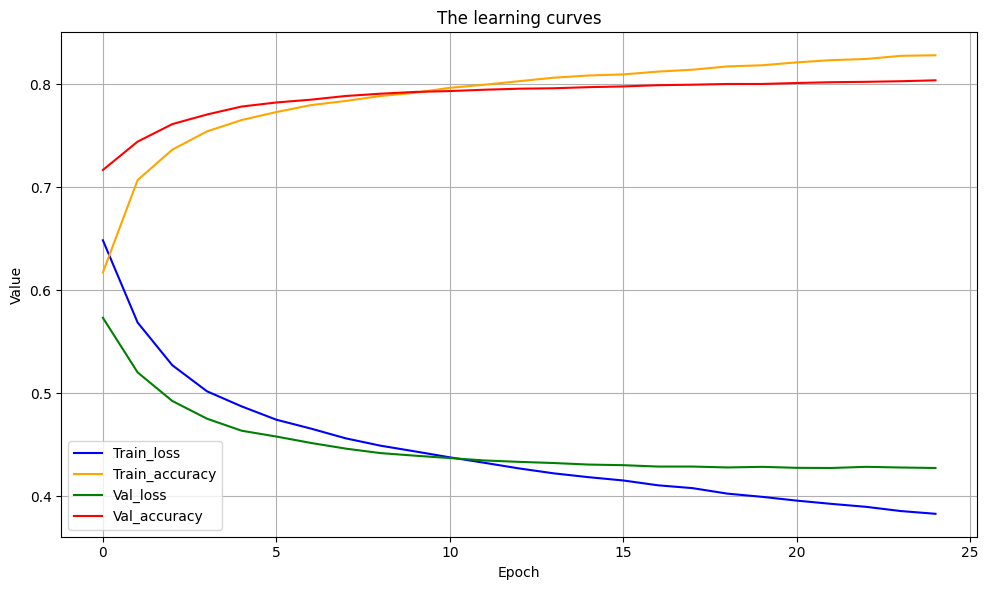

In [81]:
def learning_curve(train_losses, train_accuracies, val_losses, val_accuracies):
    #Creating the figure
    plt.figure(figsize=(10, 6))
    #Plotting the accuracies and losses
    plt.plot(train_losses, label='Train_loss', color='blue')
    plt.plot(train_accuracies, label='Train_accuracy', color='orange')
    plt.plot(val_losses, label='Val_loss', color='green')
    plt.plot(val_accuracies, label='Val_accuracy', color='red')
    #Creating the x and y labels
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.title('The learning curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    #Printing the plot
    plt.show()

learning_curve(train_losses, train_accuracies, val_losses, val_accuracies)

## ROC curve

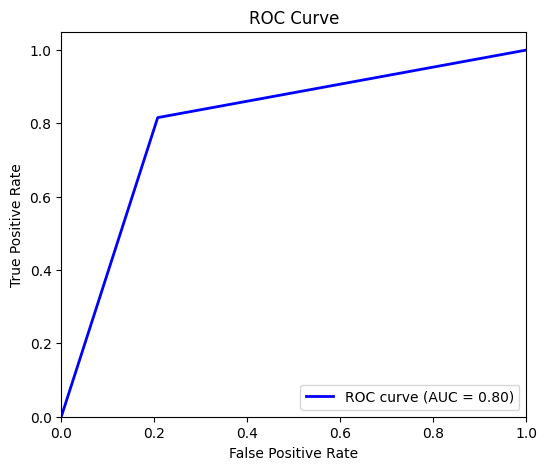

In [82]:
def ROC_curve(all_labels,all_preds):

    #Converting the labels to intergers
    all_labels = np.array(all_labels)
    all_labels = (all_labels >= 0.5).astype(int)
    #Computing the ROC curve
    fpr, tpr, thresholds = roc_curve(all_labels, all_preds)
    roc_auc = auc(fpr, tpr)
    
    #Plotting the ROC curve
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

ROC_curve(all_labels,all_preds)

## Classification Report and Confusion Matrix

              precision    recall  f1-score   support

           0       0.82      0.79      0.81     22001
           1       0.78      0.82      0.80     20395

    accuracy                           0.80     42396
   macro avg       0.80      0.80      0.80     42396
weighted avg       0.80      0.80      0.80     42396



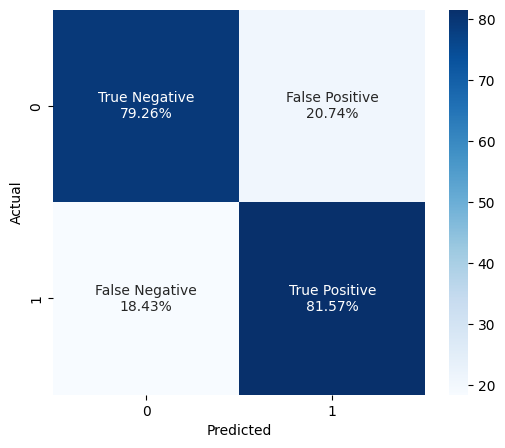

In [83]:
def cr_and_cm(all_labels,all_preds):

    #Converting the labels to intergers
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_labels = (np.array(all_labels) >= 0.5).astype(int)
    all_preds = (np.array(all_preds) >= 0.5).astype(int)
    
    #Printing the classification report
    print(classification_report(all_labels, all_preds))
    
    #Creating the confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    #Converting the values to percentages
    cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  
    #Creating the lists
    labels = np.array([["True Negative", "False Positive"], ["False Negative", "True Positive"]])
    cm_labels = np.array([[f"{labels[i, j]}\n{cm_percentage[i, j]:.2f}%" for j in range(2)] for i in range(2)])
    
    #Plotting the confusion matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_percentage, annot=cm_labels, fmt="", cmap="Blues", xticklabels=['0', '1'], yticklabels=['0', '1'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

cr_and_cm(all_labels,all_preds)

# Predictions on test and submission to competition

In [84]:
#Validation on the testing dataset
model.eval()  
predictions = []
with torch.no_grad():
    #For each batch in the testing dataloader
    for batch in test_dataloader:  
        inputs = batch
        inputs = inputs.to(device)
        #Models prediction
        outputs = model(inputs).squeeze()
        predicted = (outputs > 0.5).float().cpu().numpy()
        #Apends it to the list
        for pred in predicted:
            predictions.append(int(pred))
#Creating the predictions csv
submission = pd.DataFrame({
    "ID": test_data["ID"],  
    "Label": predictions
})
submission.to_csv("submission.csv", index=False)

# Apendices

## 1)Baseline Model

Vocabulary Coverage: 14.80%
Known tokens: 34703 out of 234493
Twitter_FFNN(
  (embedding): Embedding(234493, 200)
  (model): Sequential(
    (0): Linear(in_features=200, out_features=200, bias=True)
    (1): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=200, out_features=1, bias=True)
    (5): Sigmoid()
  )
)
Epoch [1/5], Train Loss: 0.6733, Val Loss: 0.6333, Training Accuracy: 0.5822, Validation Accuracy: 0.6530
Epoch [2/5], Train Loss: 0.6170, Val Loss: 0.5897, Training Accuracy: 0.6706, Validation Accuracy: 0.6969
Epoch [3/5], Train Loss: 0.5805, Val Loss: 0.5720, Training Accuracy: 0.7050, Validation Accuracy: 0.7075
Epoch [4/5], Train Loss: 0.5514, Val Loss: 0.5498, Training Accuracy: 0.7253, Validation Accuracy: 0.7250
Epoch [5/5], Train Loss: 0.5274, Val Loss: 0.5510, Training Accuracy: 0.7439, Validation Accuracy: 0.7206


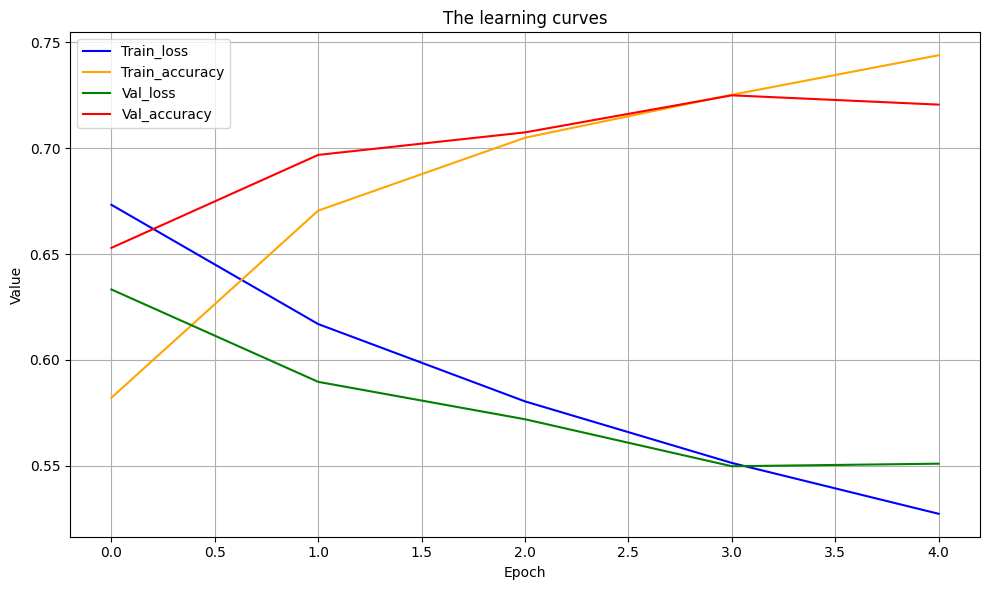

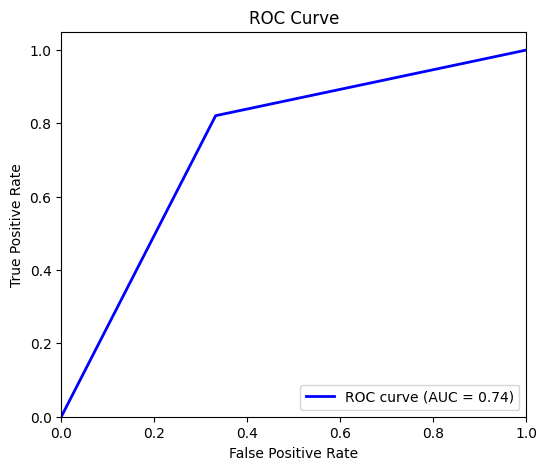

              precision    recall  f1-score   support

           0       0.88      0.67      0.76     27828
           1       0.56      0.82      0.67     14568

    accuracy                           0.72     42396
   macro avg       0.72      0.74      0.71     42396
weighted avg       0.77      0.72      0.73     42396



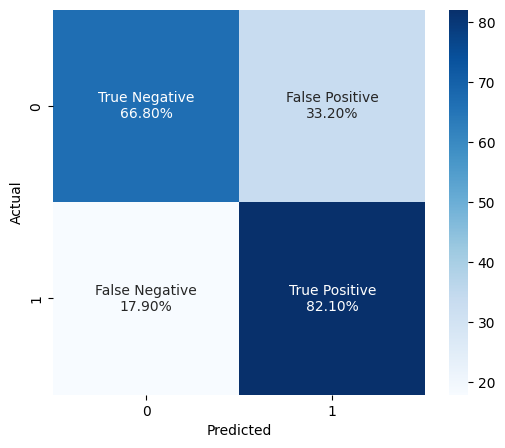

In [85]:

def tokenization(text):
    return text.split()

train_data1 = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/train_dataset.csv")
val_data1 = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/val_dataset.csv")
train_data1["tokens"] = train_data1["Text"].apply(tokenization)
val_data1["tokens"] = val_data1["Text"].apply(tokenization)

#Collecting all the unique tokens
all_tokens1 = set([token for tokens in train_data1["tokens"] for token in tokens])

#Creating a dictionary for every token
token_dict1 = {
    "PAD": 0,
    "OOV": 1
}

i = 2
for tokens in train_data1["tokens"]:
    for token in tokens:
        if token not in token_dict1:
            token_dict1[token] = i
            i += 1

#Printing all the Vocabulary coverage of the glove_model
known_tokens = 0
total_tokens = 0

for token in token_dict1.keys():
    if token in glove_model:
        known_tokens += 1
    total_tokens += 1

coverage = known_tokens / total_tokens * 100
print(f"Vocabulary Coverage: {coverage:.2f}%")
print(f"Known tokens: {known_tokens} out of {total_tokens}")

#Initializing the embedding matrix
embedding_matrix1 = np.zeros((len(token_dict1), embedding_dim))
#And adding the embeddings for all the known words
for token, i in token_dict1.items():
    if token in glove_model:
        embedding_matrix1[i] = glove_model[token]
    #If the words doesnt have an embeddings it gets a random value
    else:
        embedding_matrix1[i] = np.random.uniform(-0.1, 0.1, embedding_dim)

#Adding scaler for normalization
scaler = MinMaxScaler(feature_range=(0,1))
embedding_matrix1 = scaler.fit_transform(embedding_matrix1)

#Converting embedding matrix to tensor
embedding_matrix1 = torch.tensor(embedding_matrix1, dtype=torch.float32)

#Creating the datasets and dataloaders
train_dataset1 = create_dataset(train_data1, token_dict1, max_len=max(len(tokens) for tokens in train_data1["tokens"]))
val_dataset1 = create_dataset(val_data1, token_dict1, max_len=max(len(tokens) for tokens in val_data1["tokens"]))

train_dataloader1 = DataLoader(train_dataset1, batch_size=256, shuffle=True)
val_dataloader1 = DataLoader(val_dataset1, batch_size=256, shuffle=False)

hidden_dims1 = [200]
model1 = Twitter_FFNN(vocab_size=len(token_dict1),
         embedding_dim=embedding_dim,
         hidden_dims=hidden_dims1,
         output_dim=1,
         embedding_matrix=embedding_matrix1
         ).to(device)
print(model1)

#Initialization of loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.AdamW(model1.parameters(), lr=1e-5, weight_decay=1e-7)

train_losses, val_losses, train_accuracies, val_accuracies, all_labels, all_preds = train_model(model1, train_dataloader1, val_dataloader1, 5, 
                                                                                                optimizer, criterion)

learning_curve(train_losses, train_accuracies, val_losses, val_accuracies)
ROC_curve(all_labels,all_preds)
cr_and_cm(all_labels,all_preds)

## 2)Baseline Model with text preprocessing

Epoch [1/5], Train Loss: 0.6553, Val Loss: 0.5963, Training Accuracy: 0.6080, Validation Accuracy: 0.7056
Epoch [2/5], Train Loss: 0.5831, Val Loss: 0.5481, Training Accuracy: 0.7057, Validation Accuracy: 0.7371
Epoch [3/5], Train Loss: 0.5415, Val Loss: 0.5170, Training Accuracy: 0.7361, Validation Accuracy: 0.7533
Epoch [4/5], Train Loss: 0.5137, Val Loss: 0.4956, Training Accuracy: 0.7539, Validation Accuracy: 0.7658
Epoch [5/5], Train Loss: 0.4925, Val Loss: 0.4797, Training Accuracy: 0.7668, Validation Accuracy: 0.7741


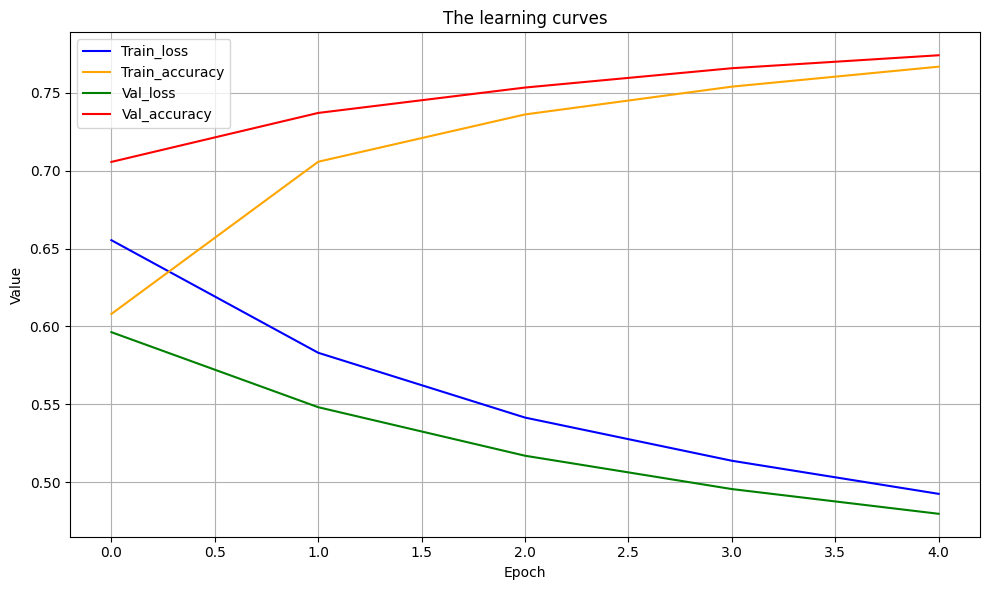

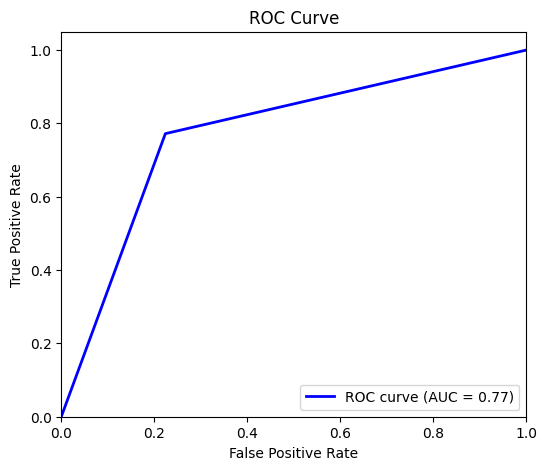

              precision    recall  f1-score   support

           0       0.77      0.78      0.77     21037
           1       0.78      0.77      0.77     21359

    accuracy                           0.77     42396
   macro avg       0.77      0.77      0.77     42396
weighted avg       0.77      0.77      0.77     42396



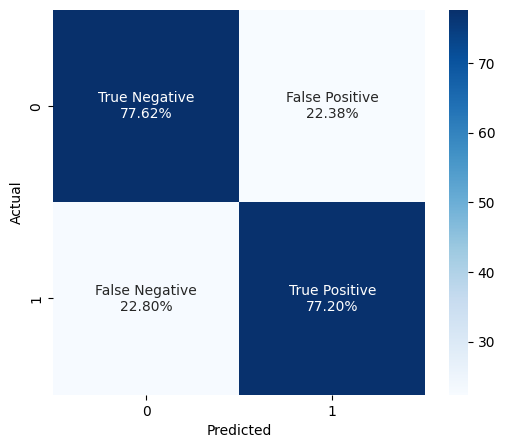

In [86]:
#Creating the datasets and dataloaders
train_dataset2 = create_dataset(train_data, token_dict_copy1, max_len=max(len(tokens) for tokens in train_data["tokens"]))
val_dataset2 = create_dataset(val_data, token_dict_copy1, max_len=max(len(tokens) for tokens in val_data["tokens"]))

train_dataloader2 = DataLoader(train_dataset2, batch_size=256, shuffle=True)
val_dataloader2 = DataLoader(val_dataset2, batch_size=256, shuffle=False)

hidden_dims21 = [200]
model21 = Twitter_FFNN(vocab_size=len(token_dict_copy1),
         embedding_dim=200,
         hidden_dims=hidden_dims21,
         output_dim=1,
         embedding_matrix=embedding_clone1,
         ).to(device)

#Initialization of loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.AdamW(model21.parameters(), lr=1e-5, weight_decay=1e-7)

train_losses, val_losses, train_accuracies, val_accuracies, all_labels, all_preds = train_model(model21, train_dataloader2, val_dataloader2, 5, 
                                                                                                optimizer, criterion)

learning_curve(train_losses, train_accuracies, val_losses, val_accuracies)
ROC_curve(all_labels, all_preds)
cr_and_cm(all_labels,all_preds)

## 3)Experimentation on hidden layers
### One model with the best hidden layers number i found(i.e. 3) and one with more hidden layers(i.e. 5)

Epoch [1/5], Train Loss: 0.6525, Val Loss: 0.5814, Training Accuracy: 0.6129, Validation Accuracy: 0.7137
Epoch [2/5], Train Loss: 0.5725, Val Loss: 0.5239, Training Accuracy: 0.7036, Validation Accuracy: 0.7433
Epoch [3/5], Train Loss: 0.5301, Val Loss: 0.4956, Training Accuracy: 0.7339, Validation Accuracy: 0.7600
Epoch [4/5], Train Loss: 0.5045, Val Loss: 0.4765, Training Accuracy: 0.7526, Validation Accuracy: 0.7707
Epoch [5/5], Train Loss: 0.4872, Val Loss: 0.4646, Training Accuracy: 0.7648, Validation Accuracy: 0.7780


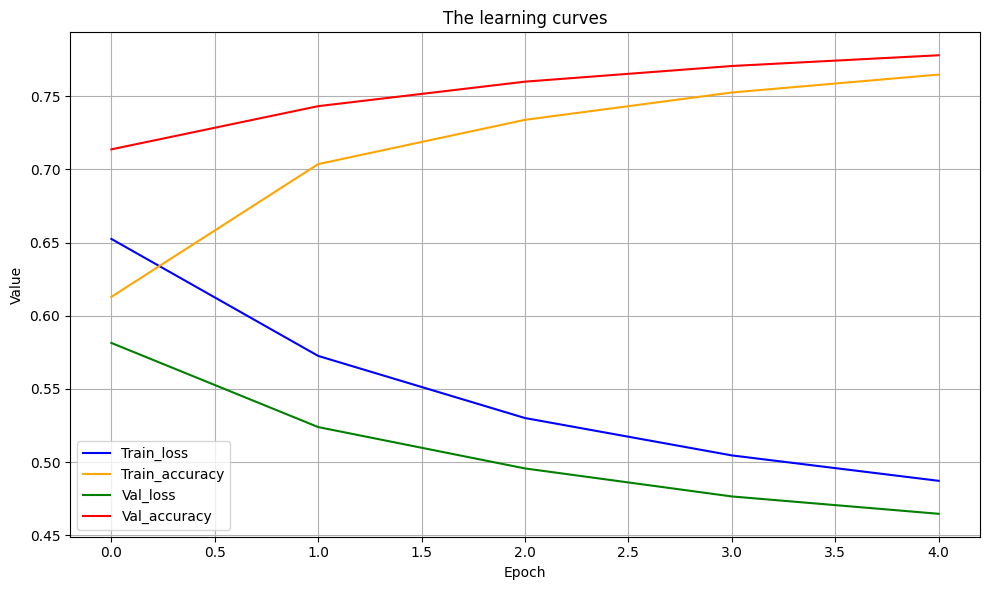

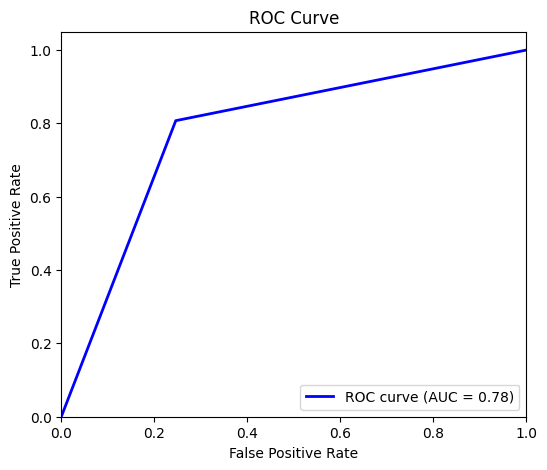

              precision    recall  f1-score   support

           0       0.83      0.75      0.79     23223
           1       0.73      0.81      0.77     19173

    accuracy                           0.78     42396
   macro avg       0.78      0.78      0.78     42396
weighted avg       0.78      0.78      0.78     42396



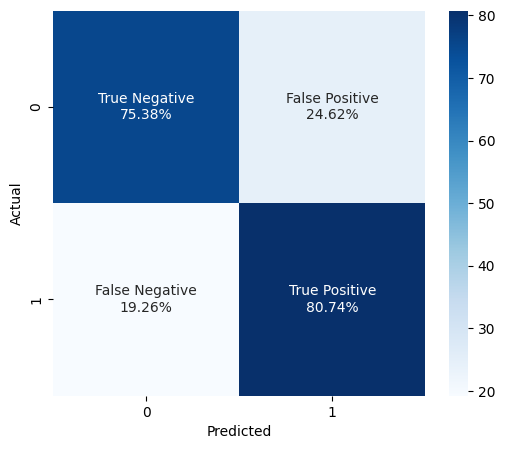

Epoch [1/5], Train Loss: 0.6982, Val Loss: 0.6508, Training Accuracy: 0.5394, Validation Accuracy: 0.6298
Epoch [2/5], Train Loss: 0.6568, Val Loss: 0.6033, Training Accuracy: 0.6073, Validation Accuracy: 0.6969
Epoch [3/5], Train Loss: 0.6139, Val Loss: 0.5646, Training Accuracy: 0.6639, Validation Accuracy: 0.7261
Epoch [4/5], Train Loss: 0.5781, Val Loss: 0.5356, Training Accuracy: 0.6998, Validation Accuracy: 0.7441
Epoch [5/5], Train Loss: 0.5507, Val Loss: 0.5124, Training Accuracy: 0.7237, Validation Accuracy: 0.7573


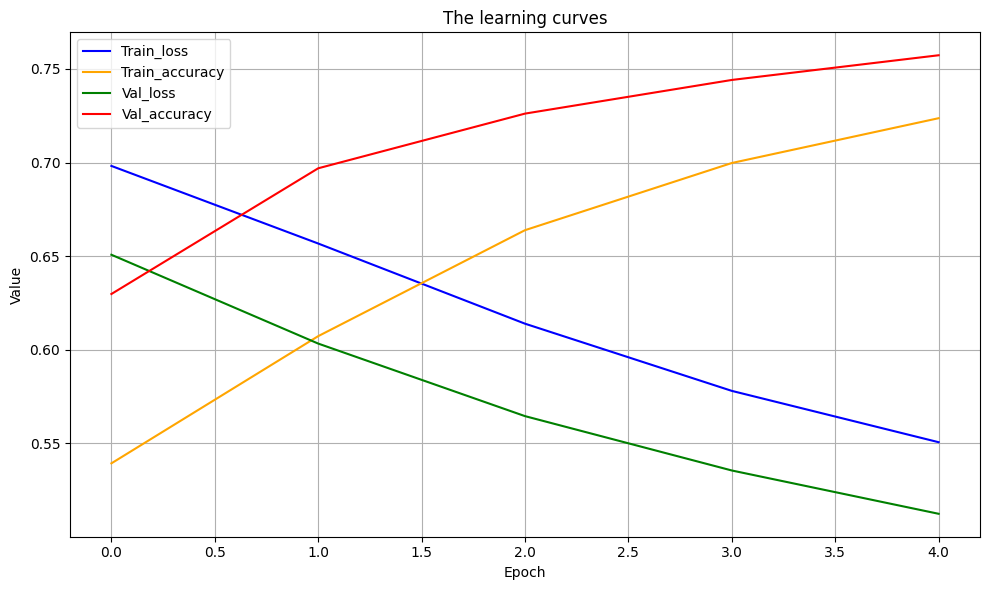

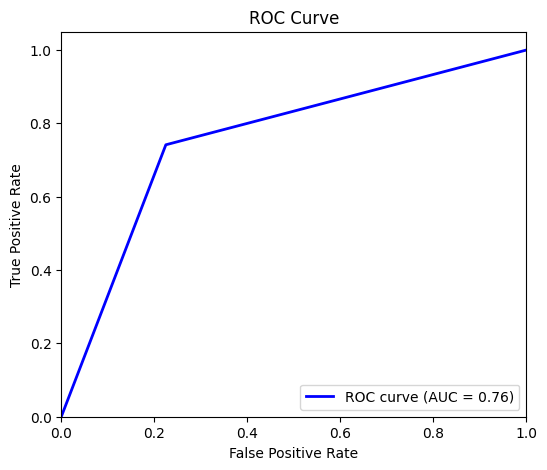

              precision    recall  f1-score   support

           0       0.72      0.78      0.75     19823
           1       0.79      0.74      0.76     22573

    accuracy                           0.76     42396
   macro avg       0.76      0.76      0.76     42396
weighted avg       0.76      0.76      0.76     42396



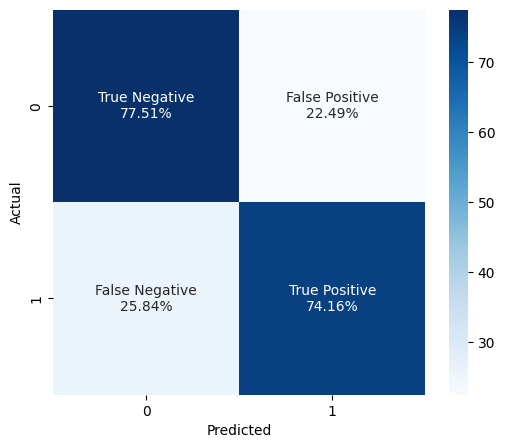

In [87]:
#Creating the datasets and dataloaders
train_dataset31 = create_dataset(train_data, token_dict_copy2, max_len=max(len(tokens) for tokens in train_data["tokens"]))
val_dataset31 = create_dataset(val_data, token_dict_copy2, max_len=max(len(tokens) for tokens in val_data["tokens"]))

train_dataloader31 = DataLoader(train_dataset31, batch_size=256, shuffle=True)
val_dataloader31 = DataLoader(val_dataset31, batch_size=256, shuffle=False)

hidden_dims31 = [512, 256, 128]
model31 = Twitter_FFNN(vocab_size=len(token_dict_copy2),
         embedding_dim=embedding_dim,
         hidden_dims=hidden_dims31,
         output_dim=1,
         embedding_matrix=embedding_clone2
         ).to(device)

criterion = nn.BCELoss()
optimizer = optim.AdamW(model31.parameters(), lr=1e-5, weight_decay=1e-7)

train_losses, val_losses, train_accuracies, val_accuracies, all_labels, all_preds = train_model(model31, train_dataloader31, val_dataloader31, 5, 
                                                                                                optimizer, criterion)

learning_curve(train_losses, train_accuracies, val_losses, val_accuracies)
ROC_curve(all_labels, all_preds)
cr_and_cm(all_labels,all_preds)

#Creating the datasets and dataloaders
train_dataset32 = create_dataset(train_data, token_dict_copy3, max_len=max(len(tokens) for tokens in train_data["tokens"]))
val_dataset32 = create_dataset(val_data, token_dict_copy3, max_len=max(len(tokens) for tokens in val_data["tokens"]))

train_dataloader32 = DataLoader(train_dataset32, batch_size=256, shuffle=True)
val_dataloader32 = DataLoader(val_dataset32, batch_size=256, shuffle=False)

hidden_dims32 = [512, 256, 128, 64, 32]
model32 = Twitter_FFNN(vocab_size=len(token_dict_copy3),
         embedding_dim=embedding_dim,
         hidden_dims=hidden_dims32,
         output_dim=1,
         embedding_matrix=embedding_clone3
         ).to(device)


criterion = nn.BCELoss()
optimizer = optim.AdamW(model32.parameters(), lr=1e-5, weight_decay=1e-7)

train_losses, val_losses, train_accuracies, val_accuracies, all_labels, all_preds = train_model(model32, train_dataloader32, val_dataloader32, 5, 
                                                                                                optimizer, criterion)

learning_curve(train_losses, train_accuracies, val_losses, val_accuracies)
ROC_curve(all_labels, all_preds)
cr_and_cm(all_labels,all_preds)

## 4)Experimentation on neurons
### One model with the best neuron number i found(i.e. 512 and dividing by power of 2) and one with less(i.e 64 and dividing by power of 2)

Epoch [1/5], Train Loss: 0.6528, Val Loss: 0.5732, Training Accuracy: 0.6107, Validation Accuracy: 0.7148
Epoch [2/5], Train Loss: 0.5687, Val Loss: 0.5180, Training Accuracy: 0.7051, Validation Accuracy: 0.7454
Epoch [3/5], Train Loss: 0.5263, Val Loss: 0.4915, Training Accuracy: 0.7362, Validation Accuracy: 0.7603
Epoch [4/5], Train Loss: 0.5020, Val Loss: 0.4742, Training Accuracy: 0.7546, Validation Accuracy: 0.7713
Epoch [5/5], Train Loss: 0.4850, Val Loss: 0.4645, Training Accuracy: 0.7650, Validation Accuracy: 0.7768


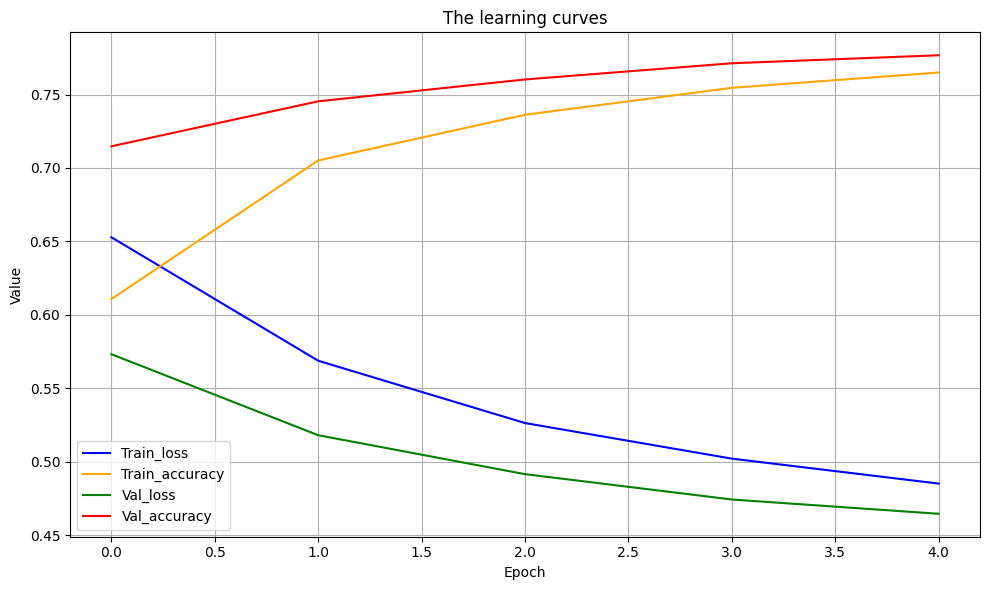

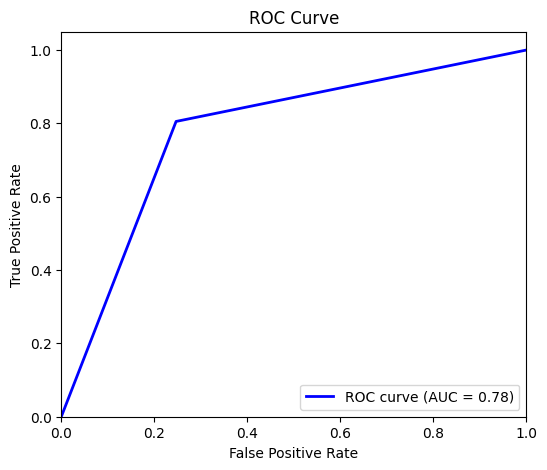

              precision    recall  f1-score   support

           0       0.82      0.75      0.79     23177
           1       0.73      0.81      0.77     19219

    accuracy                           0.78     42396
   macro avg       0.78      0.78      0.78     42396
weighted avg       0.78      0.78      0.78     42396



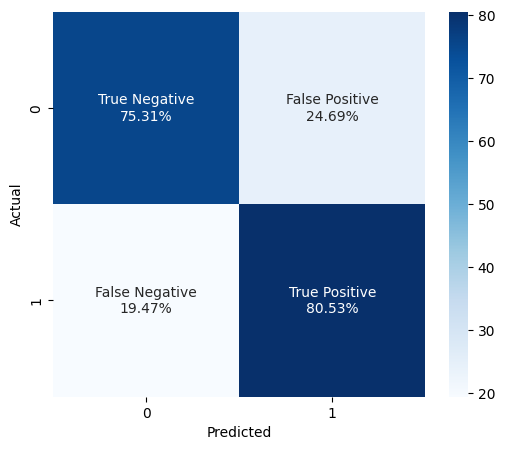

Epoch [1/5], Train Loss: 0.6978, Val Loss: 0.6764, Training Accuracy: 0.5305, Validation Accuracy: 0.5764
Epoch [2/5], Train Loss: 0.6786, Val Loss: 0.6560, Training Accuracy: 0.5750, Validation Accuracy: 0.6339
Epoch [3/5], Train Loss: 0.6606, Val Loss: 0.6351, Training Accuracy: 0.6107, Validation Accuracy: 0.6683
Epoch [4/5], Train Loss: 0.6418, Val Loss: 0.6144, Training Accuracy: 0.6429, Validation Accuracy: 0.6927
Epoch [5/5], Train Loss: 0.6222, Val Loss: 0.5921, Training Accuracy: 0.6670, Validation Accuracy: 0.7129


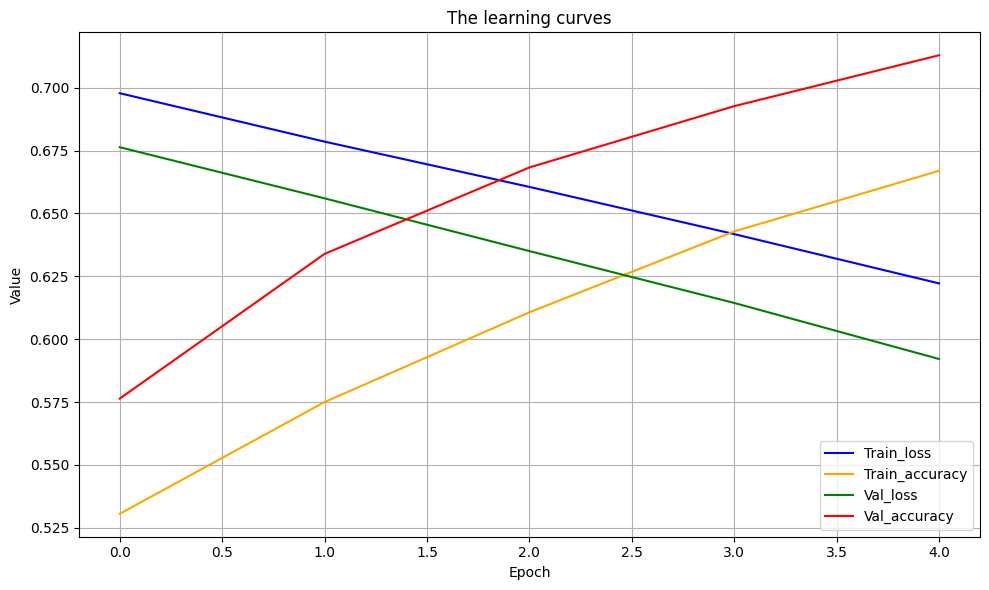

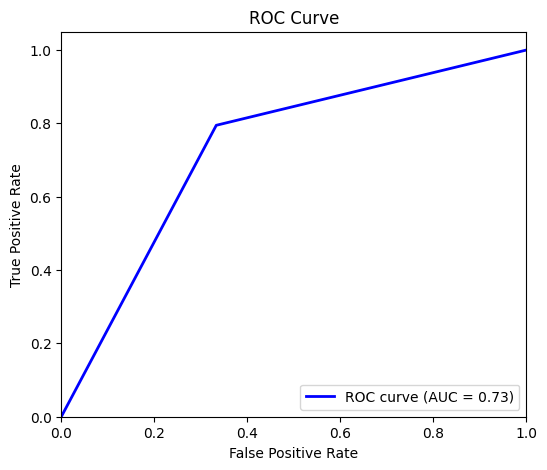

              precision    recall  f1-score   support

           0       0.85      0.67      0.75     27083
           1       0.57      0.79      0.67     15313

    accuracy                           0.71     42396
   macro avg       0.71      0.73      0.71     42396
weighted avg       0.75      0.71      0.72     42396



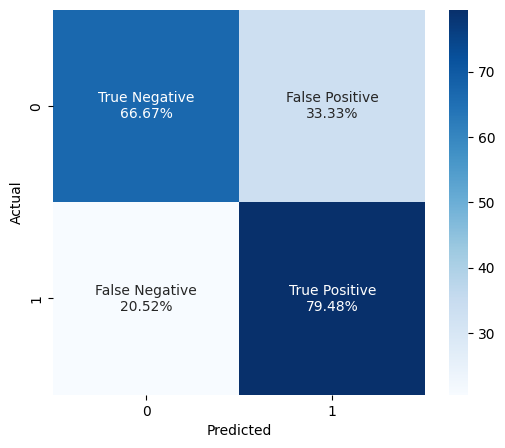

In [88]:
#Creating the datasets and dataloaders
train_dataset41 = create_dataset(train_data, token_dict_copy4, max_len=max(len(tokens) for tokens in train_data["tokens"]))
val_dataset41 = create_dataset(val_data, token_dict_copy4, max_len=max(len(tokens) for tokens in val_data["tokens"]))

train_dataloader41 = DataLoader(train_dataset41, batch_size=256, shuffle=True)
val_dataloader41 = DataLoader(val_dataset41, batch_size=256, shuffle=False)

hidden_dims41 = [512, 256, 128]
model41 = Twitter_FFNN(vocab_size=len(token_dict_copy4),
         embedding_dim=embedding_dim,
         hidden_dims=hidden_dims41,
         output_dim=1,
         embedding_matrix=embedding_clone4
         ).to(device)

criterion = nn.BCELoss()
optimizer = optim.AdamW(model41.parameters(), lr=1e-5, weight_decay=1e-7)

train_losses, val_losses, train_accuracies, val_accuracies, all_labels, all_preds = train_model(model41, train_dataloader41, val_dataloader41, 5, 
                                                                                                optimizer, criterion)

learning_curve(train_losses, train_accuracies, val_losses, val_accuracies)
ROC_curve(all_labels, all_preds)
cr_and_cm(all_labels,all_preds)

#Creating the datasets and dataloaders
train_dataset42 = create_dataset(train_data, token_dict_copy5, max_len=max(len(tokens) for tokens in train_data["tokens"]))
val_dataset42 = create_dataset(val_data, token_dict_copy5, max_len=max(len(tokens) for tokens in val_data["tokens"]))

train_dataloader42 = DataLoader(train_dataset42, batch_size=256, shuffle=True)
val_dataloader42 = DataLoader(val_dataset42, batch_size=256, shuffle=False)

hidden_dims42 = [64, 32, 16]
model42 = Twitter_FFNN(vocab_size=len(token_dict_copy5),
         embedding_dim=embedding_dim,
         hidden_dims=hidden_dims42,
         output_dim=1,
         embedding_matrix=embedding_clone5
         ).to(device)

criterion = nn.BCELoss()
optimizer = optim.AdamW(model42.parameters(), lr=1e-5, weight_decay=1e-7)

train_losses, val_losses, train_accuracies, val_accuracies, all_labels, all_preds = train_model(model42, train_dataloader42, val_dataloader42, 5, 
                                                                                                optimizer, criterion)

learning_curve(train_losses, train_accuracies, val_losses, val_accuracies)
ROC_curve(all_labels, all_preds)
cr_and_cm(all_labels,all_preds)

## 5)Experimentation on epochs
### One model with the best epoch number i found(i.e. 25), one with less epochs(i.e. 5 presented in the experiment 4.1) and one with more epochs(i.e. 29)

Epoch [1/25], Train Loss: 0.6516, Val Loss: 0.5839, Training Accuracy: 0.6163, Validation Accuracy: 0.7111
Epoch [2/25], Train Loss: 0.5736, Val Loss: 0.5261, Training Accuracy: 0.7021, Validation Accuracy: 0.7410
Epoch [3/25], Train Loss: 0.5300, Val Loss: 0.4947, Training Accuracy: 0.7345, Validation Accuracy: 0.7593
Epoch [4/25], Train Loss: 0.5033, Val Loss: 0.4754, Training Accuracy: 0.7530, Validation Accuracy: 0.7713
Epoch [5/25], Train Loss: 0.4863, Val Loss: 0.4647, Training Accuracy: 0.7643, Validation Accuracy: 0.7777
Epoch [6/25], Train Loss: 0.4735, Val Loss: 0.4576, Training Accuracy: 0.7737, Validation Accuracy: 0.7819
Epoch [7/25], Train Loss: 0.4632, Val Loss: 0.4518, Training Accuracy: 0.7796, Validation Accuracy: 0.7846
Epoch [8/25], Train Loss: 0.4554, Val Loss: 0.4467, Training Accuracy: 0.7849, Validation Accuracy: 0.7873
Epoch [9/25], Train Loss: 0.4490, Val Loss: 0.4421, Training Accuracy: 0.7883, Validation Accuracy: 0.7914
Epoch [10/25], Train Loss: 0.4419, Va

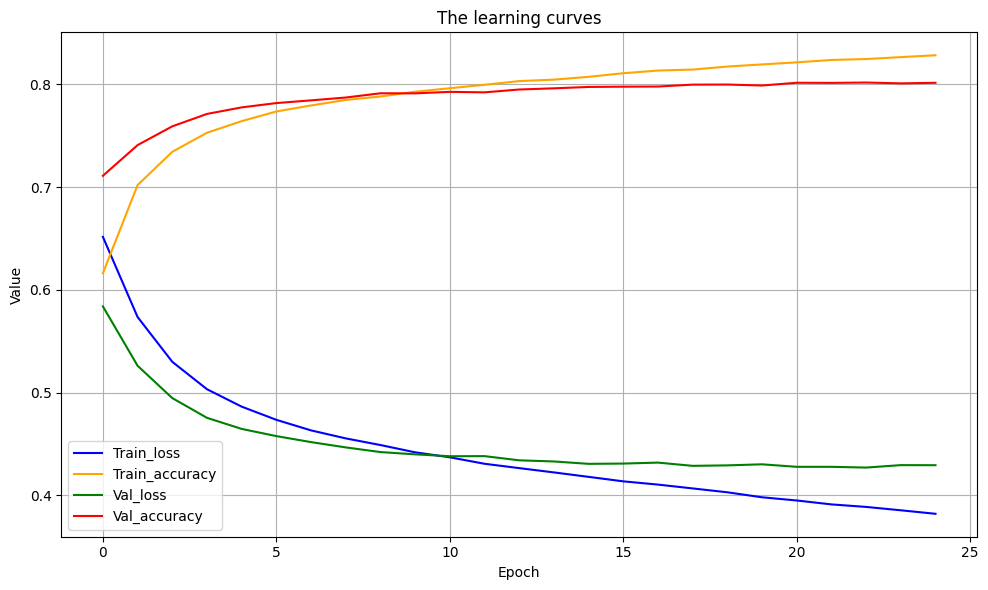

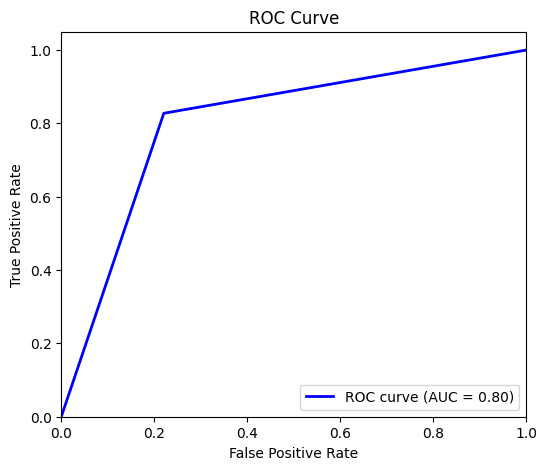

              precision    recall  f1-score   support

           0       0.84      0.78      0.81     22874
           1       0.76      0.83      0.79     19522

    accuracy                           0.80     42396
   macro avg       0.80      0.80      0.80     42396
weighted avg       0.80      0.80      0.80     42396



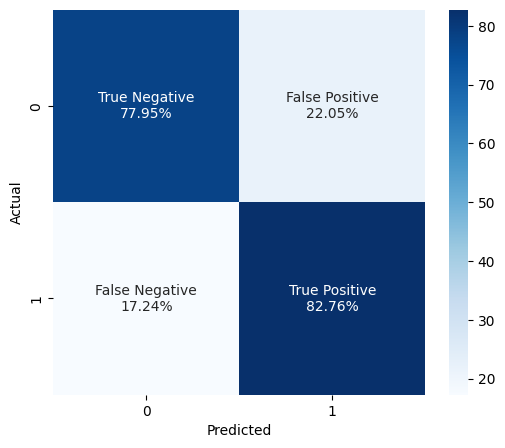

Epoch [1/29], Train Loss: 0.6523, Val Loss: 0.5767, Training Accuracy: 0.6107, Validation Accuracy: 0.7120
Epoch [2/29], Train Loss: 0.5710, Val Loss: 0.5243, Training Accuracy: 0.7028, Validation Accuracy: 0.7416
Epoch [3/29], Train Loss: 0.5306, Val Loss: 0.4962, Training Accuracy: 0.7344, Validation Accuracy: 0.7583
Epoch [4/29], Train Loss: 0.5049, Val Loss: 0.4775, Training Accuracy: 0.7520, Validation Accuracy: 0.7692
Epoch [5/29], Train Loss: 0.4877, Val Loss: 0.4656, Training Accuracy: 0.7640, Validation Accuracy: 0.7752
Epoch [6/29], Train Loss: 0.4753, Val Loss: 0.4573, Training Accuracy: 0.7715, Validation Accuracy: 0.7811
Epoch [7/29], Train Loss: 0.4659, Val Loss: 0.4526, Training Accuracy: 0.7776, Validation Accuracy: 0.7835
Epoch [8/29], Train Loss: 0.4571, Val Loss: 0.4481, Training Accuracy: 0.7831, Validation Accuracy: 0.7855
Epoch [9/29], Train Loss: 0.4503, Val Loss: 0.4444, Training Accuracy: 0.7870, Validation Accuracy: 0.7882
Epoch [10/29], Train Loss: 0.4437, Va

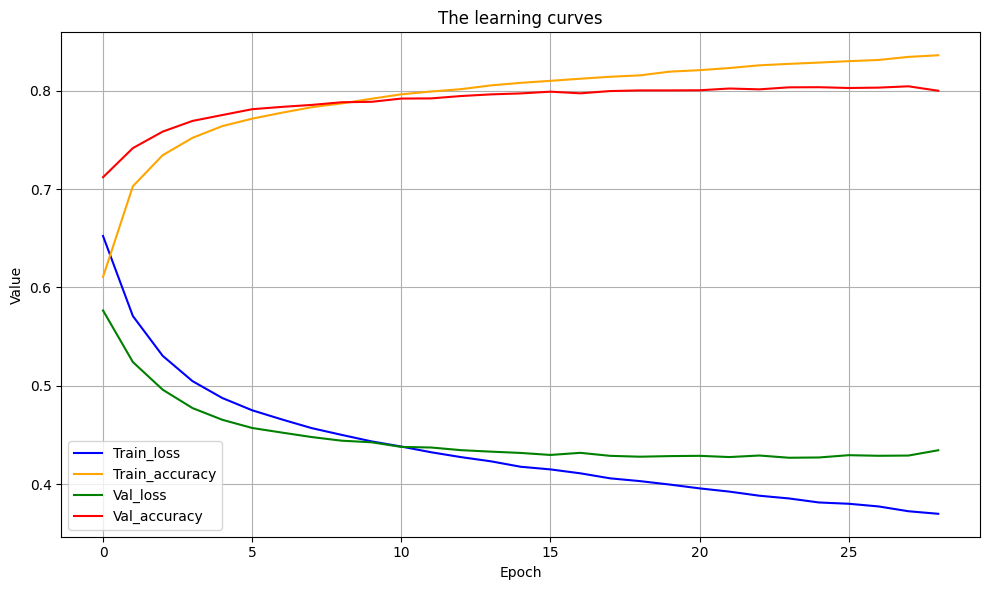

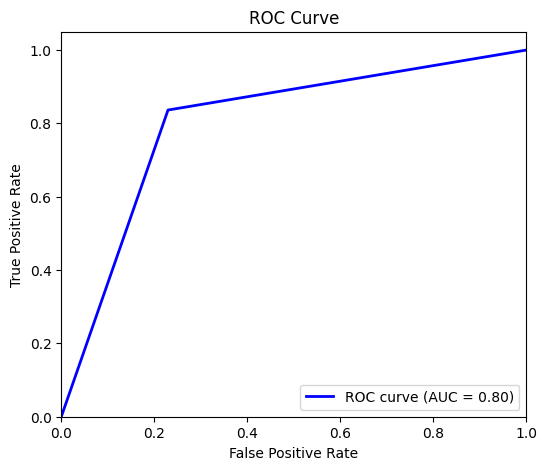

              precision    recall  f1-score   support

           0       0.85      0.77      0.81     23500
           1       0.75      0.84      0.79     18896

    accuracy                           0.80     42396
   macro avg       0.80      0.80      0.80     42396
weighted avg       0.81      0.80      0.80     42396



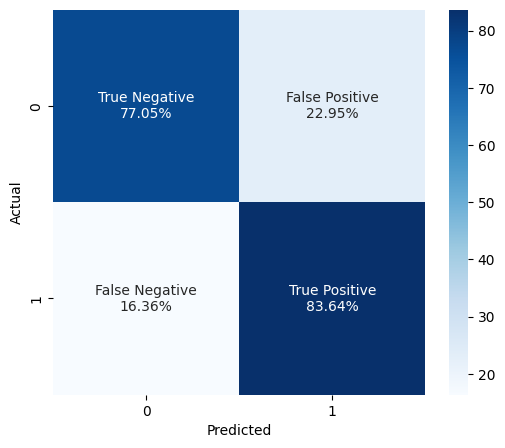

In [89]:
#Creating the datasets and dataloaders
train_dataset51 = create_dataset(train_data, token_dict_copy6, max_len=max(len(tokens) for tokens in train_data["tokens"]))
val_dataset51 = create_dataset(val_data, token_dict_copy6, max_len=max(len(tokens) for tokens in val_data["tokens"]))

train_dataloader51 = DataLoader(train_dataset51, batch_size=256, shuffle=True)
val_dataloader51 = DataLoader(val_dataset51, batch_size=256, shuffle=False)

hidden_dims51 = [512, 256, 128]
model51 = Twitter_FFNN(vocab_size=len(token_dict_copy6),
         embedding_dim=embedding_dim,
         hidden_dims=hidden_dims51,
         output_dim=1,
         embedding_matrix=embedding_clone6
         ).to(device)

criterion = nn.BCELoss()
optimizer = optim.AdamW(model51.parameters(), lr=1e-5, weight_decay=1e-7)

train_losses, val_losses, train_accuracies, val_accuracies, all_labels, all_preds = train_model(model51, train_dataloader51, val_dataloader51, 25, 
                                                                                                optimizer, criterion)

learning_curve(train_losses, train_accuracies, val_losses, val_accuracies)
ROC_curve(all_labels, all_preds)
cr_and_cm(all_labels,all_preds)

#Creating the datasets and dataloaders
train_dataset52 = create_dataset(train_data, token_dict_copy7, max_len=max(len(tokens) for tokens in train_data["tokens"]))
val_dataset52 = create_dataset(val_data, token_dict_copy7, max_len=max(len(tokens) for tokens in val_data["tokens"]))

train_dataloader52 = DataLoader(train_dataset52, batch_size=256, shuffle=True)
val_dataloader52 = DataLoader(val_dataset52, batch_size=256, shuffle=False)

hidden_dims52 = [512, 256, 128]
model52 = Twitter_FFNN(vocab_size=len(token_dict_copy7),
         embedding_dim=embedding_dim,
         hidden_dims=hidden_dims52,
         output_dim=1,
         embedding_matrix=embedding_clone7
         ).to(device)

criterion = nn.BCELoss()
optimizer = optim.AdamW(model52.parameters(), lr=1e-5, weight_decay=1e-7)

train_losses, val_losses, train_accuracies, val_accuracies, all_labels, all_preds = train_model(model52, train_dataloader52, val_dataloader52, 29, 
                                                                                                optimizer, criterion)

learning_curve(train_losses, train_accuracies, val_losses, val_accuracies)
ROC_curve(all_labels, all_preds)
cr_and_cm(all_labels,all_preds)

## 6)Experimentation on learning rate and weight decay
### One model with the best learning rate and weight decay i managed to find(i.e. lr=1e-5,wd=1e-7 presented in experiment 5.1) and one with a worse one(i.e. lr=1e-2,wd=1e-4)

Epoch [1/5], Train Loss: 0.4724, Val Loss: 0.4648, Training Accuracy: 0.7765, Validation Accuracy: 0.7846
Epoch [2/5], Train Loss: 0.3651, Val Loss: 0.4802, Training Accuracy: 0.8364, Validation Accuracy: 0.7729
Epoch [3/5], Train Loss: 0.2987, Val Loss: 0.5615, Training Accuracy: 0.8703, Validation Accuracy: 0.7809
Epoch [4/5], Train Loss: 0.2499, Val Loss: 0.6018, Training Accuracy: 0.8937, Validation Accuracy: 0.7615
Epoch [5/5], Train Loss: 0.2111, Val Loss: 0.6131, Training Accuracy: 0.9111, Validation Accuracy: 0.7642


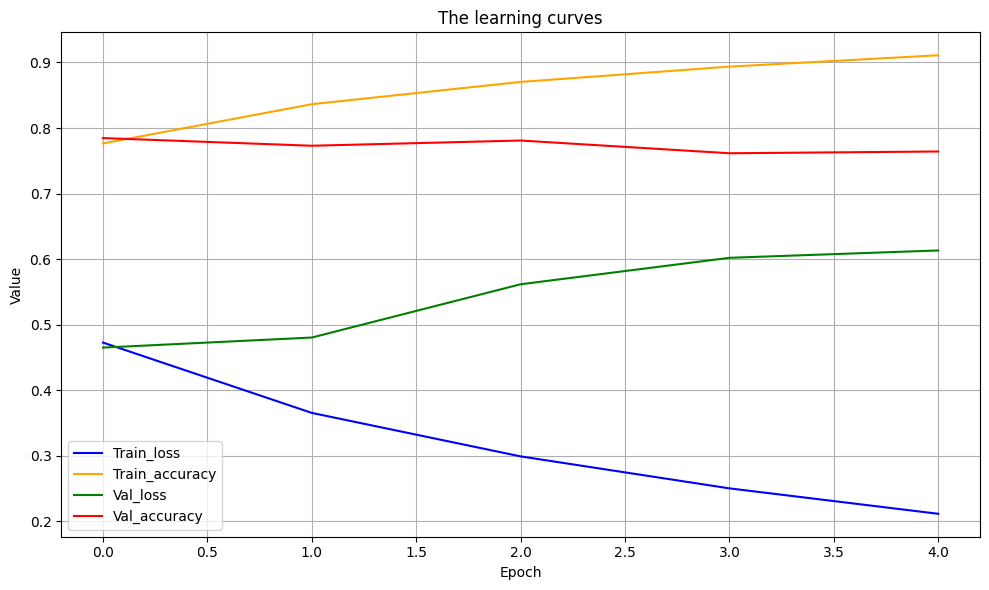

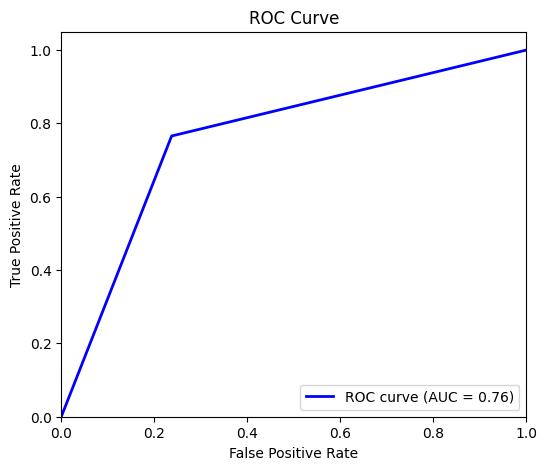

              precision    recall  f1-score   support

           0       0.77      0.76      0.76     21314
           1       0.76      0.77      0.76     21082

    accuracy                           0.76     42396
   macro avg       0.76      0.76      0.76     42396
weighted avg       0.76      0.76      0.76     42396



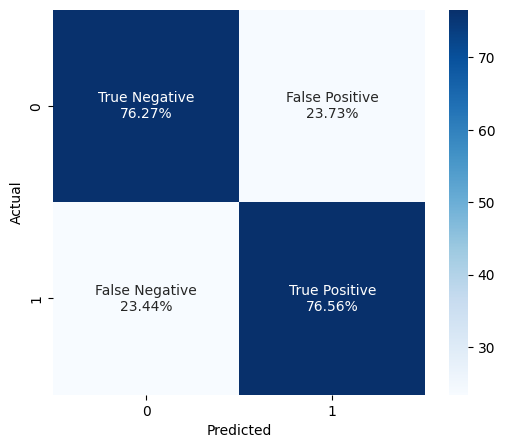

In [90]:
#Creating the datasets and dataloaders
train_dataset6 = create_dataset(train_data, token_dict_copy8, max_len=max(len(tokens) for tokens in train_data["tokens"]))
val_dataset6 = create_dataset(val_data, token_dict_copy8, max_len=max(len(tokens) for tokens in val_data["tokens"]))

train_dataloader6 = DataLoader(train_dataset6, batch_size=256, shuffle=True)
val_dataloader6 = DataLoader(val_dataset6, batch_size=256, shuffle=False)

hidden_dims6 = [512, 256, 128]
model6 = Twitter_FFNN(vocab_size=len(token_dict_copy8),
         embedding_dim=embedding_dim,
         hidden_dims=hidden_dims6,
         output_dim=1,
         embedding_matrix=embedding_clone8
         ).to(device)

criterion = nn.BCELoss()
optimizer = optim.AdamW(model6.parameters(), lr=1e-2, weight_decay=1e-4)

train_losses, val_losses, train_accuracies, val_accuracies, all_labels, all_preds = train_model(model6, train_dataloader6, val_dataloader6, 5, 
                                                                                                optimizer, criterion)

learning_curve(train_losses, train_accuracies, val_losses, val_accuracies)
ROC_curve(all_labels, all_preds)
cr_and_cm(all_labels,all_preds)